In [1]:
!pip install --upgrade eispy2d


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.5/278.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 70.0 MB/s eta 0:00:00


## 0. Importing Files

In [14]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

from eispy2d.api import benchmark_api as bmk
from eispy2d.core import result as rst

# Importa o benchmark salvo pelo gerador.
# No Colab, coloque o arquivo "api_benchmark" no diretório de trabalho.
mybmk = bmk.Benchmark('void')
mybmk.importdata('api_benchmark')

print(mybmk)


BENCHMARK (API)
Name: api_benchmark
Wavelength: None
Image size: None
Number measurements: None
Number sources: None
Observation radius: None
Resolution: None
Background permittivity: None
Noise level: None
Shape: None
Sample size: None
Results: done
Algorithm: None
Test set: benchmark_tests
Configurations: None



## 1. Getting Results


In [15]:
algorithm_names = [
    'Born Approximation',
    'Born Iterative Method',
    'Contrast Source Inversion',
    'Sum Approximation'
]

results = np.asarray(mybmk.results)

print(f"Results shape: {results.shape}")

if results.ndim != 2:
    raise ValueError(
        f"Formato inesperado: {results.shape}. "
        "Como o benchmark possui vários algoritmos, um único TestSet "
        "e nenhuma configuração manual, o formato esperado é "
        "(n_algorithms, n_tests)."
    )

n_algorithms, n_tests = results.shape

if n_algorithms != len(algorithm_names):
    raise ValueError(
        f"Número de algoritmos nos resultados ({n_algorithms}) "
        f"não corresponde a algorithm_names ({len(algorithm_names)})."
    )

testset = mybmk.testset
tests = testset.test

if len(tests) != n_tests:
    raise ValueError(
        f"O benchmark possui {n_tests} resultados por algoritmo, "
        f"mas o TestSet possui {len(tests)} testes."
    )

print(f"Número de algoritmos: {n_algorithms}")
print(f"Número de testes: {n_tests}")
print(f"Resolução: {testset.resolution}")
print(f"Noise level padrão do TestSet: {testset.noise_level}")


Results shape: (4, 300)
Número de algoritmos: 4
Número de testes: 300
Resolução: (30, 30)
Noise level padrão do TestSet: 1.0


In [16]:
def extract_indicator(results, indicator):
    values = []

    for r in results:
        if hasattr(r, indicator):
            val = getattr(r, indicator)

            if isinstance(val, list) and len(val) > 0:
                values.append(val[-1])
            elif isinstance(val, (int, float, np.integer, np.floating)):
                values.append(val)
            else:
                values.append(np.nan)
        else:
            values.append(np.nan)

    return np.asarray(values, dtype=float)


def get_test_param(test, key, default=np.nan):
    return test.get(key, default)


def get_test_label(test):
    return (
        f"shape={test.get('shape')}, "
        f"eps={test.get('background_permittivity')}, "
        f"NM={test.get('number_measurements')}, "
        f"NS={test.get('number_sources')}, "
        f"noise={test.get('noise_level')}"
    )


def get_indicator_data(algorithm_index, test_indices, indicator):
    data = results[algorithm_index, test_indices]

    return extract_indicator(data, indicator)


# Mostra os primeiros testes para conferir os parâmetros realmente
# armazenados no benchmark.
print("Primeiros testes do benchmark:")
print("-" * 80)

for i, test in enumerate(tests[:10]):
    print(f"Test {i}: {get_test_label(test)}")

print("-" * 80)


Primeiros testes do benchmark:
--------------------------------------------------------------------------------
Test 0: shape=triangle, eps=1.0, NM=8, NS=8, noise=1.0
Test 1: shape=triangle, eps=1.0, NM=8, NS=16, noise=1.0
Test 2: shape=triangle, eps=1.0, NM=8, NS=32, noise=1.0
Test 3: shape=triangle, eps=1.0, NM=16, NS=8, noise=1.0
Test 4: shape=triangle, eps=1.0, NM=16, NS=16, noise=1.0
Test 5: shape=triangle, eps=1.0, NM=16, NS=32, noise=1.0
Test 6: shape=triangle, eps=1.0, NM=32, NS=8, noise=1.0
Test 7: shape=triangle, eps=1.0, NM=32, NS=16, noise=1.0
Test 8: shape=triangle, eps=1.0, NM=32, NS=32, noise=1.0
Test 9: shape=triangle, eps=2.0, NM=8, NS=8, noise=1.0
--------------------------------------------------------------------------------


## 2. Cofigurations extracted from results


In [17]:
def unique_values(key):
    return list(dict.fromkeys(
        test.get(key)
        for test in tests
        if key in test
    ))


group_indices = {}

for key, group_name in [
    ('shape', 'shapes'),
    ('noise_level', 'noise'),
    ('background_permittivity', 'permittivity'),
    ('number_sources', 'sources'),
]:
    values = unique_values(key)

    group_indices[group_name] = {
        value: [
            i for i, test in enumerate(tests)
            if test.get(key) == value
        ]
        for value in values
    }

print("Configurações encontradas nos testes:")
print("-" * 80)

for group_name, groups in group_indices.items():
    print(f"\n{group_name.upper()}:")

    for value, indices in groups.items():
        print(f"  {value}: testes {indices}")

print("-" * 80)


Configurações encontradas nos testes:
--------------------------------------------------------------------------------

SHAPES:
  triangle: testes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
  square: testes [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]
  circle: testes [72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107]
  ellipse: testes [108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143]
  cross: testes [144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 

## 3. Shape variation


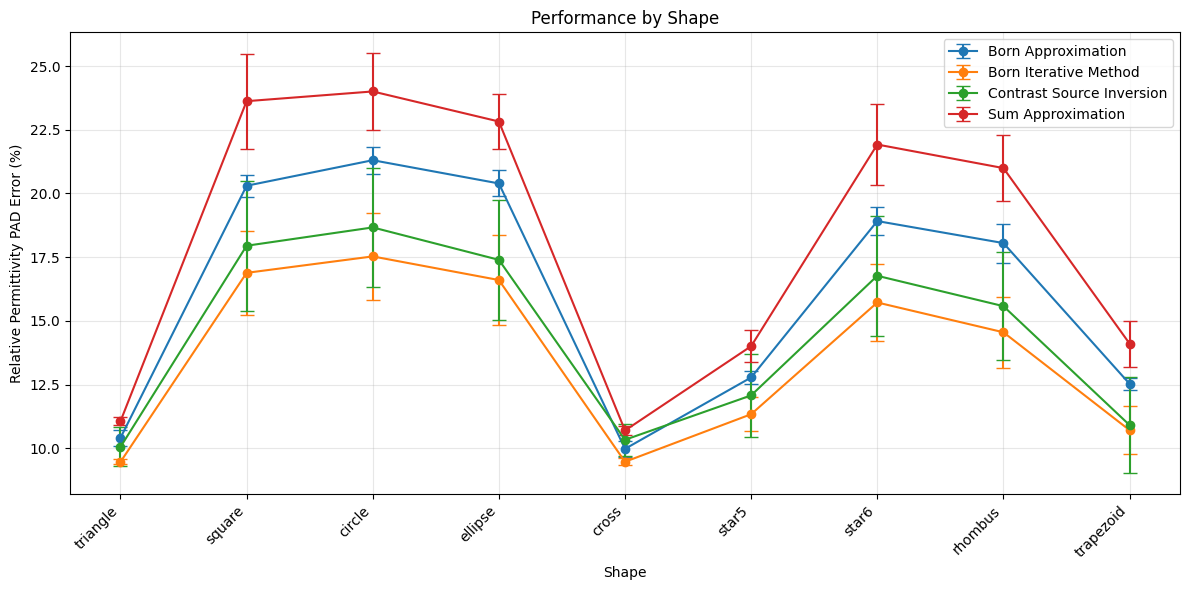

In [18]:
indicator = rst.REL_PERMITTIVITY_PAD_ERROR
shape_groups = group_indices['shapes']

fig, ax = plt.subplots(figsize=(12, 6))
has_data = False

shape_values = list(shape_groups.keys())

for a_idx, name in enumerate(algorithm_names):
    means = []
    stds = []
    labels = []

    for shape in shape_values:
        indices = shape_groups[shape]
        data = get_indicator_data(a_idx, indices, indicator)
        valid = data[~np.isnan(data)]

        if len(valid) > 0:
            means.append(np.mean(valid))
            stds.append(np.std(valid))
            labels.append(str(shape))

    if means:
        has_data = True
        x = np.arange(len(means))

        ax.errorbar(
            x, means, yerr=stds,
            marker='o', label=name, capsize=5
        )

if has_data:
    ax.set_xlabel('Shape')
    ax.set_ylabel('Relative Permittivity PAD Error (%)')
    ax.set_title('Performance by Shape')
    ax.set_xticks(np.arange(len(shape_values)))
    ax.set_xticklabels(shape_values, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No valid data available for shape analysis")


## 4. Noise variation




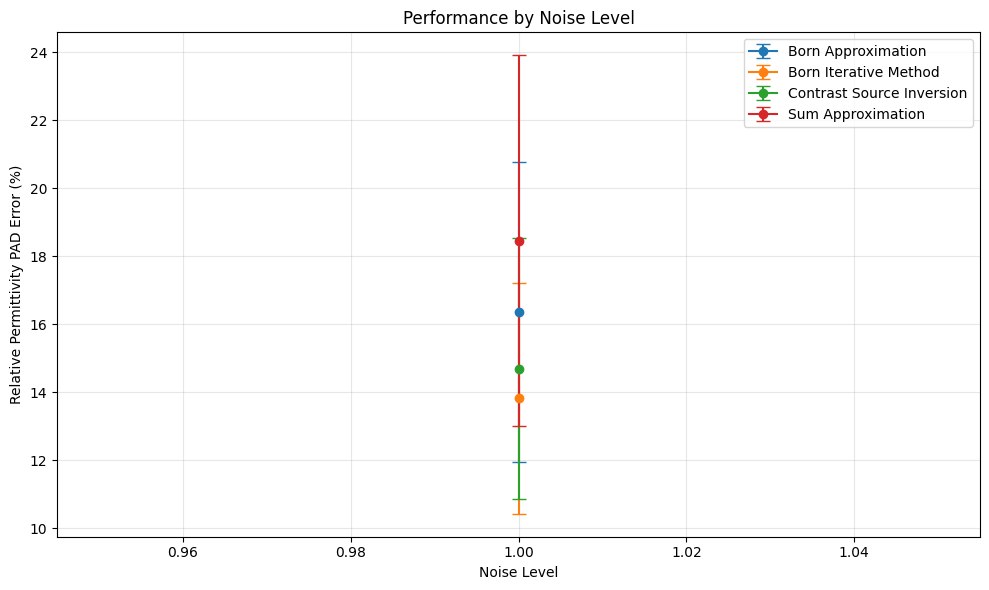

In [19]:
noise_groups = group_indices['noise']

fig, ax = plt.subplots(figsize=(10, 6))
has_data = False

for a_idx, name in enumerate(algorithm_names):
    means = []
    stds = []
    x = []

    for noise, indices in noise_groups.items():
        data = get_indicator_data(a_idx, indices, indicator)
        valid = data[~np.isnan(data)]

        if len(valid) > 0:
            means.append(np.mean(valid))
            stds.append(np.std(valid))
            x.append(noise)

    if means:
        has_data = True

        ax.errorbar(
            x, means, yerr=stds,
            marker='o', label=name, capsize=5, linestyle='-'
        )

if has_data:
    ax.set_xlabel('Noise Level')
    ax.set_ylabel('Relative Permittivity PAD Error (%)')
    ax.set_title('Performance by Noise Level')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No valid data available for noise analysis")


## 5. Background permittivity variation


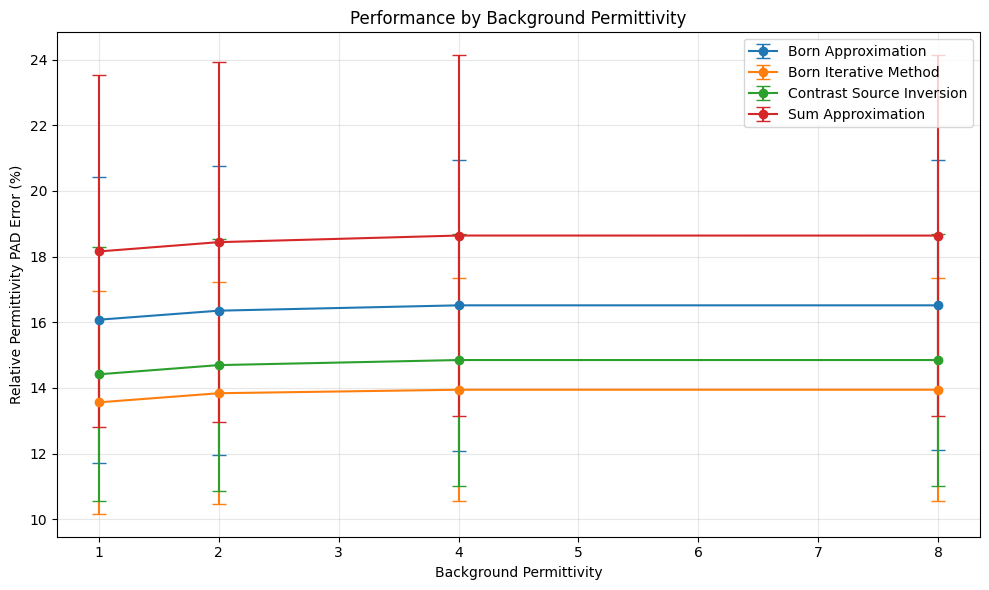

In [20]:
perm_groups = group_indices['permittivity']

fig, ax = plt.subplots(figsize=(10, 6))
has_data = False

for a_idx, name in enumerate(algorithm_names):
    means = []
    stds = []
    x = []

    for eps, indices in perm_groups.items():
        data = get_indicator_data(a_idx, indices, indicator)
        valid = data[~np.isnan(data)]

        if len(valid) > 0:
            means.append(np.mean(valid))
            stds.append(np.std(valid))
            x.append(eps)

    if means:
        has_data = True

        ax.errorbar(
            x, means, yerr=stds,
            marker='o', label=name, capsize=5, linestyle='-'
        )

if has_data:
    ax.set_xlabel('Background Permittivity')
    ax.set_ylabel('Relative Permittivity PAD Error (%)')
    ax.set_title('Performance by Background Permittivity')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No valid data available for permittivity analysis")


## 6. Sources and measurements


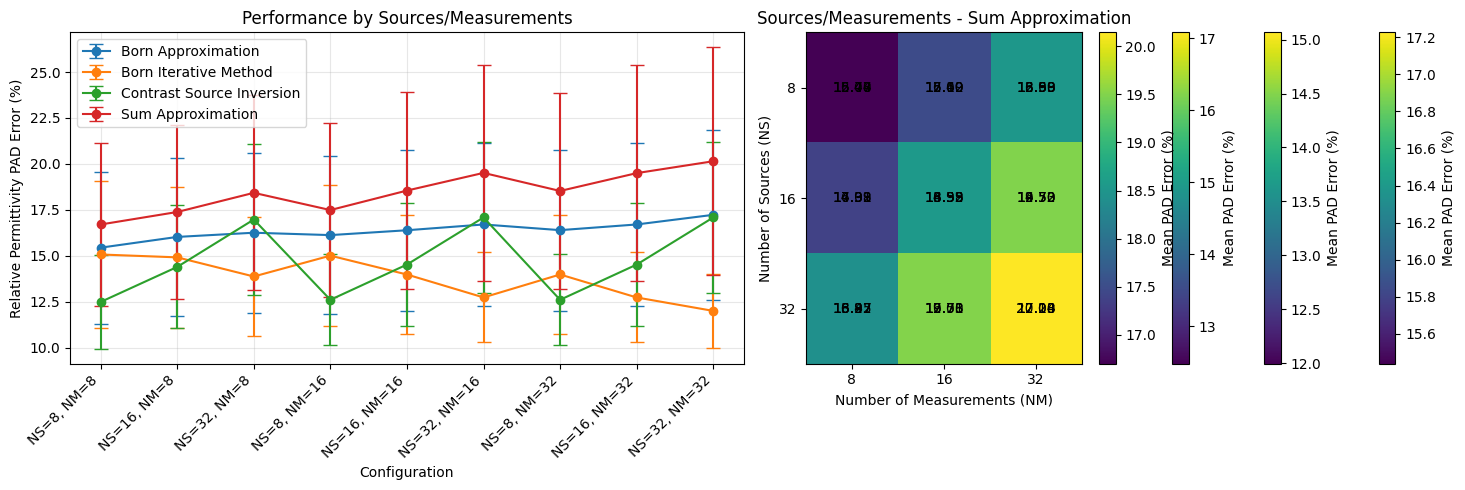

In [21]:
source_groups = {}

for i, test in enumerate(tests):
    key = (
        test.get('number_sources'),
        test.get('number_measurements')
    )

    source_groups.setdefault(key, []).append(i)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

has_data = False
source_labels = list(source_groups.keys())


for a_idx, name in enumerate(algorithm_names):
    means = []
    stds = []

    for key in source_labels:
        indices = source_groups[key]
        data = get_indicator_data(a_idx, indices, indicator)
        valid = data[~np.isnan(data)]

        if len(valid) > 0:
            means.append(np.mean(valid))
            stds.append(np.std(valid))

    if means:
        has_data = True
        x = np.arange(len(means))

        axes[0].errorbar(
            x, means, yerr=stds,
            marker='o', label=name, capsize=5
        )

if has_data:
    axes[0].set_xlabel('Configuration')
    axes[0].set_ylabel('Relative Permittivity PAD Error (%)')
    axes[0].set_title('Performance by Sources/Measurements')
    axes[0].set_xticks(np.arange(len(source_labels)))
    axes[0].set_xticklabels(
        [f"NS={ns}, NM={nm}" for ns, nm in source_labels],
        rotation=45,
        ha='right'
    )
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Segundo gráfico: matriz NS x NM.
for a_idx, name in enumerate(algorithm_names):
    ns_values = sorted(set(k[0] for k in source_groups))
    nm_values = sorted(set(k[1] for k in source_groups))

    matrix = np.full((len(ns_values), len(nm_values)), np.nan)

    for (ns, nm), indices in source_groups.items():
        data = get_indicator_data(a_idx, indices, indicator)
        valid = data[~np.isnan(data)]

        if len(valid) > 0:
            i_ns = ns_values.index(ns)
            i_nm = nm_values.index(nm)
            matrix[i_ns, i_nm] = np.mean(valid)

    if np.isfinite(matrix).any():
        im = axes[1].imshow(matrix, aspect='auto')

        axes[1].set_xticks(np.arange(len(nm_values)))
        axes[1].set_yticks(np.arange(len(ns_values)))
        axes[1].set_xticklabels(nm_values)
        axes[1].set_yticklabels(ns_values)

        axes[1].set_xlabel('Number of Measurements (NM)')
        axes[1].set_ylabel('Number of Sources (NS)')
        axes[1].set_title(f'Sources/Measurements - {name}')

        for i in range(len(ns_values)):
            for j in range(len(nm_values)):
                if not np.isnan(matrix[i, j]):
                    axes[1].text(
                        j, i, f"{matrix[i, j]:.2f}",
                        ha='center', va='center'
                    )

        fig.colorbar(im, ax=axes[1], label='Mean PAD Error (%)')

plt.tight_layout()
plt.show()


## 7. Comparing algorithms

In [22]:
print("\n=== Best Test per Algorithm ===\n")

for a_idx, name in enumerate(algorithm_names):
    data = extract_indicator(results[a_idx], indicator)
    valid_indices = np.where(~np.isnan(data))[0]

    if len(valid_indices) == 0:
        print(f"{name}: no valid data\n")
        continue

    best_idx = valid_indices[np.argmin(data[valid_indices])]

    print(f"{name}:")
    print(f"  Test index: {best_idx}")
    print(f"  Test: {get_test_label(tests[best_idx])}")
    print(f"  Error: {data[best_idx]:.4f}")
    print()



=== Best Test per Algorithm ===

Born Approximation:
  Test index: 162
  Test: shape=cross, eps=4.0, NM=8, NS=8, noise=1.0
  Error: 9.3759

Born Iterative Method:
  Test index: 296
  Test: shape=trapezoid, eps=1.0, NM=32, NS=32, noise=1.0
  Error: 8.9853

Contrast Source Inversion:
  Test index: 294
  Test: shape=trapezoid, eps=1.0, NM=32, NS=8, noise=1.0
  Error: 8.7222

Sum Approximation:
  Test index: 171
  Test: shape=cross, eps=8.0, NM=8, NS=8, noise=1.0
  Error: 10.3262



## 8. Algorithm comparison


In [23]:
print("\n=== Algorithms per Test ===\n")

for t_idx, test in enumerate(tests):
    print(f"Test {t_idx}: {get_test_label(test)}")

    values = []

    for a_idx, name in enumerate(algorithm_names):
        value = extract_indicator(
            results[a_idx, t_idx:t_idx + 1],
            indicator
        )[0]

        values.append(value)

        if np.isnan(value):
            print(f"  {name}: no valid data")
        else:
            print(f"  {name}: {value:.4f}")

    valid = np.asarray(values)
    if np.isfinite(valid).any():
        best_idx = np.nanargmin(valid)
        print(f"  Lowest error in this test: {algorithm_names[best_idx]}")
    else:
        print("  No valid result")

    print()



=== Algorithms per Test ===

Test 0: shape=triangle, eps=1.0, NM=8, NS=8, noise=1.0
  Born Approximation: 9.8047
  Born Iterative Method: 9.5527
  Contrast Source Inversion: 9.2750
  Sum Approximation: 10.7717
  Lowest error in this test: Contrast Source Inversion

Test 1: shape=triangle, eps=1.0, NM=8, NS=16, noise=1.0
  Born Approximation: 10.1517
  Born Iterative Method: 9.5951
  Contrast Source Inversion: 9.7465
  Sum Approximation: 10.9545
  Lowest error in this test: Born Iterative Method

Test 2: shape=triangle, eps=1.0, NM=8, NS=32, noise=1.0
  Born Approximation: 10.4396
  Born Iterative Method: 9.4496
  Contrast Source Inversion: 11.1091
  Sum Approximation: 11.0715
  Lowest error in this test: Born Iterative Method

Test 3: shape=triangle, eps=1.0, NM=16, NS=8, noise=1.0
  Born Approximation: 10.1569
  Born Iterative Method: 9.5987
  Contrast Source Inversion: 9.3021
  Sum Approximation: 10.9128
  Lowest error in this test: Contrast Source Inversion

Test 4: shape=triangle,

## 9. Statistics


In [24]:
print("\n=== Summary Statistics ===\n")

for a_idx, name in enumerate(algorithm_names):
    data = extract_indicator(results[a_idx], indicator)
    valid = data[~np.isnan(data)]

    if len(valid) > 0:
        print(f"{name}:")
        print(f"  Mean: {np.mean(valid):.4f}")
        print(f"  Std: {np.std(valid):.4f}")
        print(f"  Min: {np.min(valid):.4f}")
        print(f"  Max: {np.max(valid):.4f}")
        print(f"  N: {len(valid)}")
        print()
    else:
        print(f"{name}: no valid data\n")



=== Summary Statistics ===

Born Approximation:
  Mean: 16.3560
  Std: 4.4019
  Min: 9.3759
  Max: 22.2480
  N: 300

Born Iterative Method:
  Mean: 13.8143
  Std: 3.3952
  Min: 8.9853
  Max: 19.7637
  N: 300

Contrast Source Inversion:
  Mean: 14.6930
  Std: 3.8478
  Min: 8.7222
  Max: 21.6561
  N: 300

Sum Approximation:
  Mean: 18.4589
  Std: 5.4536
  Min: 10.3262
  Max: 26.4711
  N: 300



## 10. Boxplots by configuration groups


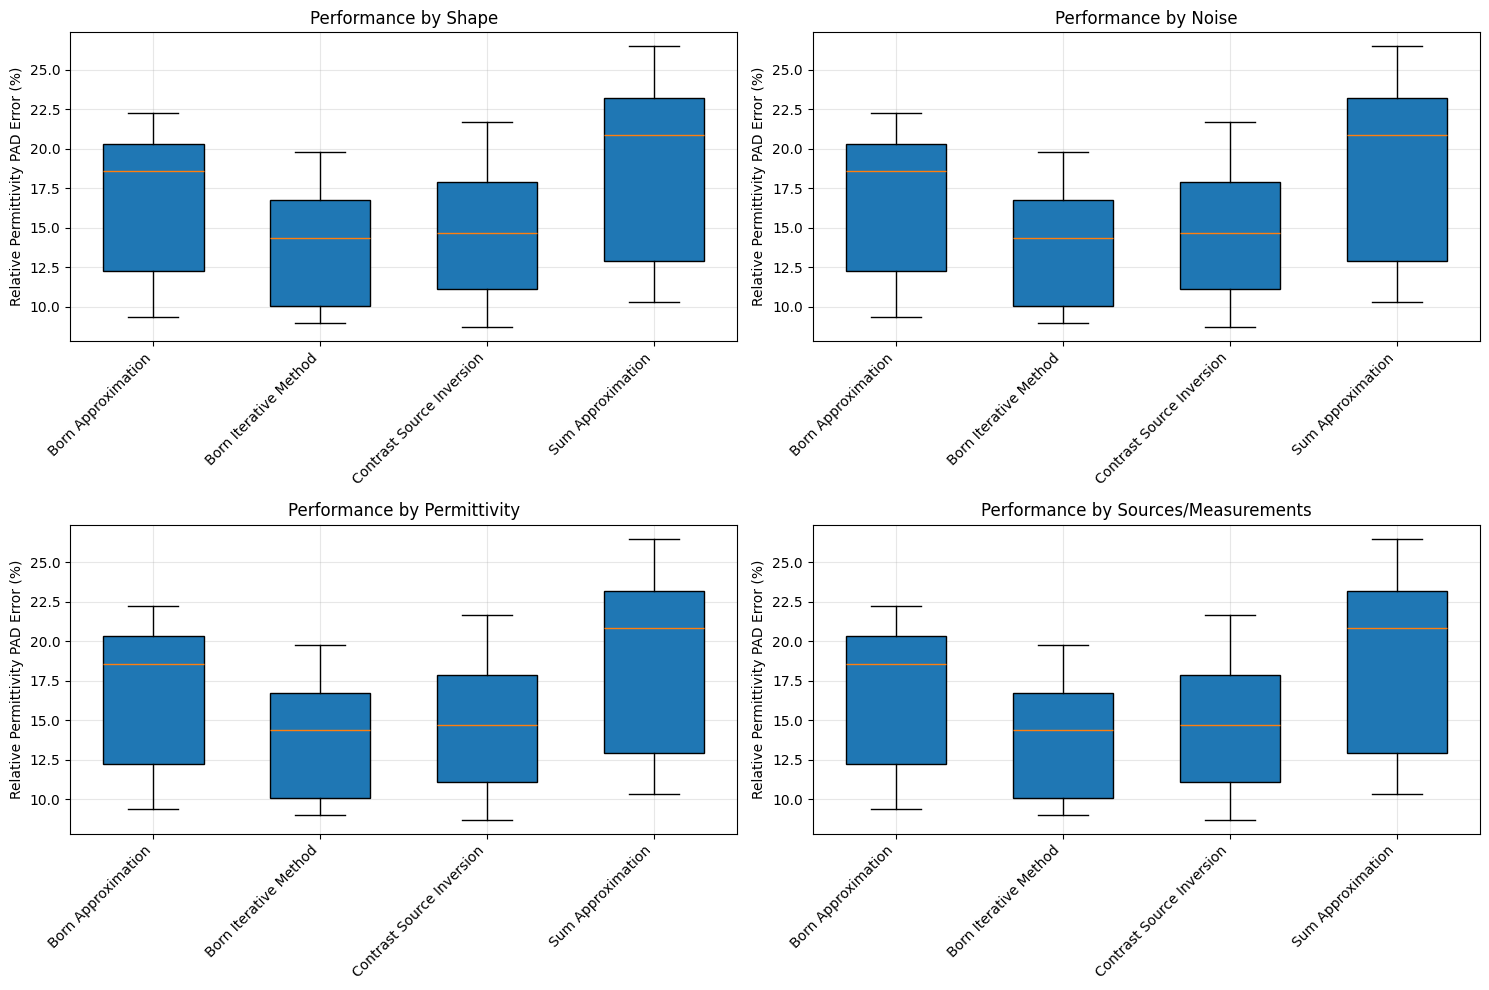

In [25]:
group_configs = [
    ('Shape', group_indices['shapes']),
    ('Noise', group_indices['noise']),
    ('Permittivity', group_indices['permittivity']),
    ('Sources/Measurements', source_groups)
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, (group_name, groups) in zip(axes, group_configs):
    has_data = False

    for a_idx, name in enumerate(algorithm_names):
        data = []

        for _, indices in groups.items():
            d = get_indicator_data(a_idx, indices, indicator)
            valid = d[~np.isnan(d)]
            data.extend(valid)

        if len(data) > 0:
            has_data = True

            ax.boxplot(
                data,
                positions=[a_idx + 1],
                widths=0.6,
                patch_artist=True
            )

    if has_data:
        ax.set_xticks(range(1, len(algorithm_names) + 1))
        ax.set_xticklabels(
            algorithm_names,
            rotation=45,
            ha='right'
        )
        ax.set_ylabel('Relative Permittivity PAD Error (%)')
        ax.set_title(f'Performance by {group_name}')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(
            0.5, 0.5,
            f'No data for {group_name}',
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()
